## AgriBrain: AI-Powered Agricultural Market Intelligence System.

AgriBrain is an end-to-end agritech recommendation engine that leverages real-time soil, weather, and market data to optimize crop selection for Kenyan farmers. The platform actively combats the agricultural "Cobweb Phenomenon"- a cycle of market oversupply and price crashes caused by farmer reliance in past planted crops and historical prices as their main source of choice. By utilizing predictive machibe learning and an LLM-driven market analysis agent, AgriBrain breaks this cycle by recommending high-demand, ecologically viable viable alternative crops that maximize harvest profitability.





## Key Stakeholders
1. Farmers(Primary users)
- Need guidance on **what to grow** and **when to grow**

- This will help them **avoid overproduction** and **maximize profits**

2. Government and Policy Makers
- Use insights for **food security planning** and **import and export decision** and also **issue early warnings for shortages**


## Business Problem
The current project will help solve the current challenges that the farmers are facing such as **relying in guesswork** and **use of past experience** which often leads to oversupply and price crashes and shortages which leads to food insecurity. **This predictve intelligence will combine different data and use machine learning to guide farmers in their agricultural decisions**

###
- Dasasets used.
- Blueprint of our notebook

# Dataset 1: Yield

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

yield_df = pd.read_csv('yield.csv.csv')
yield_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'yield.csv.csv'

In [ ]:
print(yield_df.shape)
print("\nColumns:")
print(yield_df.columns.tolist())

(4396, 15)

Columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


## Renaming columns to lowercase

In [ ]:
yield_df = yield_df.rename(columns={
    "Area": "area",
    "Item": "item",
    "Year" : "year",
    "Unit" :"unit",
    "Value": "yield_kg_per_ha"
    
})

## Fixing the year datatype

In [ ]:
yield_df['year'] = yield_df['year'].astype(int)

## Checking for duplicates

In [ ]:
print( "Total number of duplicate rows:", yield_df.duplicated().sum())

Total number of duplicate rows: 0


In [ ]:
# Final clean dataset
yield_clean = yield_df[['item','year','unit','yield_kg_per_ha']].copy()

In [ ]:
print(yield_clean.shape)
print(yield_clean.head())

(4396, 4)
                      item  year   unit  yield_kg_per_ha
0  Abaca, manila hemp, raw  1991  kg/ha           1139.6
1  Abaca, manila hemp, raw  1992  kg/ha           1125.0
2  Abaca, manila hemp, raw  1993  kg/ha           1154.3
3  Abaca, manila hemp, raw  1994  kg/ha           1139.7
4  Abaca, manila hemp, raw  1995  kg/ha           1126.1


## Exploratory Data Analysis

In [ ]:
print(yield_clean.info())
print("\nSummary Statistics:")
print(yield_clean.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item             4396 non-null   object 
 1   year             4396 non-null   int64  
 2   unit             4396 non-null   object 
 3   yield_kg_per_ha  4396 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 137.5+ KB
None

Summary Statistics:
              year  yield_kg_per_ha
count  4396.000000      4396.000000
mean   1996.414468      7076.352116
std      17.810920     11569.827178
min    1961.000000        33.300000
25%    1982.000000       833.300000
50%    1998.000000      4000.000000
75%    2011.000000      9760.350000
max    2024.000000    121184.500000


## Top Crops by average yield

In [ ]:
top_crops = (yield_clean.groupby('item')['yield_kg_per_ha']
             .mean()
             .sort_values(ascending=False)
             .head(15))

print("\nTop 15 Crops by Average Yield (kg/ha):")
print(top_crops)


Top 15 Crops by Average Yield (kg/ha):
item
Sugar cane                       76965.676562
Pineapples                       39807.071875
Cabbages                         24246.673529
Carrots and turnips              19456.739394
Watermelons                      17306.766667
Tomatoes                         16656.681250
Bananas                          14548.820312
Avocados                         14324.610937
Spinach                          14237.400000
Cauliflowers and broccoli        14188.621212
Plantains and cooking bananas    13356.946875
Green garlic                     13250.003125
Lettuce and chicory              12049.385294
Papayas                          11373.837500
Cucumbers and gherkins           10137.300000
Name: yield_kg_per_ha, dtype: float64


## VISUALIZATION

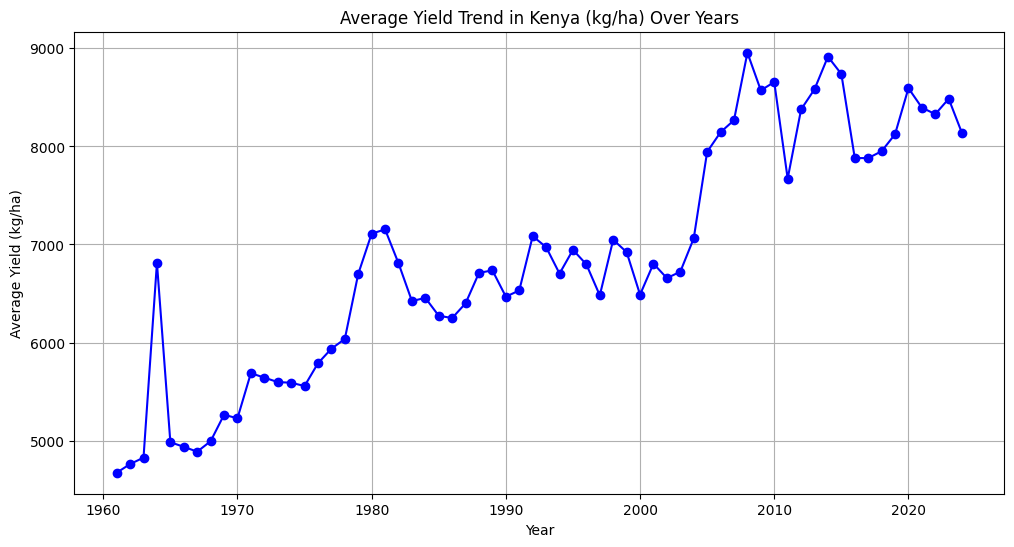

In [ ]:
plt.figure(figsize=(12,6))
yield_clean.groupby('year')['yield_kg_per_ha'].mean().plot(kind='line',marker='o',color='blue')
plt.title('Average Yield Trend in Kenya (kg/ha) Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.grid(True)
plt.show()

# Dataset 2: Food Balance (Food)

In [ ]:
import pandas as pd

fdbalance_df = pd.read_csv("Data\FAOSTAT_data_commodity balances_food.csv")
print(fdbalance_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Data\\FAOSTAT_data_commodity balances_food.csv'

#### From this dataset the strongest feature is:
#### National_Stock_Deficit_Ratio
##### * (Consumption - Production) / Production

In [ ]:
fdbalance_df.columns


Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (FBS)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='str')

In [ ]:
fdbalance_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20167 entries, 0 to 20166
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       20167 non-null  str    
 1   Domain            20167 non-null  str    
 2   Area Code (M49)   20167 non-null  int64  
 3   Area              20167 non-null  str    
 4   Element Code      20167 non-null  int64  
 5   Element           20167 non-null  str    
 6   Item Code (FBS)   20167 non-null  str    
 7   Item              20167 non-null  str    
 8   Year Code         20167 non-null  int64  
 9   Year              20167 non-null  int64  
 10  Unit              20167 non-null  str    
 11  Value             20167 non-null  float64
 12  Flag              20167 non-null  str    
 13  Flag Description  20167 non-null  str    
 14  Note              0 non-null      float64
dtypes: float64(2), int64(4), str(9)
memory usage: 2.3 MB


In [ ]:
fdbalance_df['Element'].unique()

<StringArray>
[         'Total Population - Both sexes',
                             'Production',
                        'Import quantity',
                        'Stock Variation',
                        'Export quantity',
               'Domestic supply quantity',
                                   'Feed',
                                   'Seed',
                                 'Losses',
                             'Processing',
                  'Other uses (non-food)',
                    'Tourist consumption',
                              'Residuals',
                                   'Food',
    'Food supply quantity (kg/capita/yr)',
          'Food supply (kcal/capita/day)',
                     'Food supply (kcal)',
 'Protein supply quantity (g/capita/day)',
            'Protein supply quantity (t)',
     'Fat supply quantity (g/capita/day)',
                'Fat supply quantity (t)']
Length: 21, dtype: str

In [ ]:
fdbalance_df['Item'].unique()

<StringArray>
[                     'Population',              'Wheat and products',
               'Rice and products',             'Barley and products',
              'Maize and products',                'Rye and products',
                            'Oats',             'Millet and products',
            'Sorghum and products',                  'Cereals, other',
            'Cassava and products',           'Potatoes and products',
                  'Sweet potatoes',                            'Yams',
                    'Roots, Other',                      'Sugar cane',
                      'Sugar beet',           'Sugar non-centrifugal',
          'Sugar (Raw Equivalent)',               'Sweeteners, Other',
                           'Honey',                           'Beans',
                            'Peas',      'Pulses, Other and products',
               'Nuts and products',                       'Soyabeans',
                      'Groundnuts',                  'Sunflower

## Transform the dataset

In [ ]:
print("shape:", fdbalance_df.shape)
print("\ncolumns:")
print(fdbalance_df.columns.tolist())

print("\nunique units:")
print(fdbalance_df["Unit"].value_counts(dropna=False))

print("\nunique elements:")
print(fdbalance_df["Element"].value_counts(dropna=False))

shape: (20167, 15)

columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (FBS)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']

unique units:
Unit
1000 t          11548
g/cap/d          2448
t                2448
kg/cap           1261
kcal/cap/d       1224
million Kcal     1224
1000 No            14
Name: count, dtype: int64

unique elements:
Element
Domestic supply quantity                  1343
Export quantity                           1272
Food                                      1261
Food supply quantity (kg/capita/yr)       1261
Import quantity                           1257
Food supply (kcal/capita/day)             1224
Food supply (kcal)                        1224
Protein supply quantity (g/capita/day)    1224
Protein supply quantity (t)               1224
Fat supply quantity (g/capita/day)        1224
Fat supply quantity (t)                   1224
Residuals                                 1189


In [ ]:
elements_to_keep = [
    "Production",
    "Import quantity",
    "Export quantity",
    "Domestic supply quantity",
    "Food",
    "Feed",
    "Seed",
    "Processing",
    "Losses",
    "Stock Variation",
    "Other uses (non-food)"
]

In [ ]:
# Filter by unit
fdbalance_clean = fdbalance_df[fdbalance_df["Unit"] == "1000 t"]

# Filter by elements
elements_to_keep = [
    "Production",
    "Import quantity",
    "Export quantity",
    "Domestic supply quantity",
    "Food",
    "Feed",
    "Seed",
    "Processing",
    "Losses",
    "Stock Variation",
    "Other uses (non-food)"
]

fdbalance_clean = fdbalance_clean[
    fdbalance_clean["Element"].isin(elements_to_keep)
]

print("new shape:", fdbalance_clean.shape)
print("\nremaining elements:")
print(fdbalance_clean["Element"].value_counts())

new shape: (9289, 15)

remaining elements:
Element
Domestic supply quantity    1343
Export quantity             1272
Food                        1261
Import quantity             1257
Stock Variation             1147
Production                  1112
Losses                       667
Processing                   393
Feed                         349
Seed                         263
Other uses (non-food)        225
Name: count, dtype: int64


## Pivoting
Converting the units under elements ccolumn from long format (Element as rows) to wide format (Element as columns)

In [ ]:
fdbalance_pivot = fdbalance_clean.pivot_table(
    index=["Area", "Item", "Year"],
    columns="Element",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column name grouping
fdbalance_pivot.columns.name = None

print("shape:", fdbalance_pivot.shape)
print("\ncolumns:")
print(fdbalance_pivot.columns.tolist())

shape: (1343, 14)

columns:
['Area', 'Item', 'Year', 'Domestic supply quantity', 'Export quantity', 'Feed', 'Food', 'Import quantity', 'Losses', 'Other uses (non-food)', 'Processing', 'Production', 'Seed', 'Stock Variation']


#### Now  the columns are:
* Area
* Item
* Year
* Production
* Import quantity
* Export quantity
* Food
* Feed
* Processing
* Losses etc.

Each row = one crop in one year

## Final cleaning

In [ ]:
fdbalance_final = fdbalance_pivot.copy()

fdbalance_final.columns = [
    col.lower().replace(" ", "_").replace("(", "").replace(")", "")
    for col in fdbalance_final.columns
]

print(fdbalance_final.columns.tolist())

['area', 'item', 'year', 'domestic_supply_quantity', 'export_quantity', 'feed', 'food', 'import_quantity', 'losses', 'other_uses_non-food', 'processing', 'production', 'seed', 'stock_variation']


## Creating the core features

In [ ]:
# Supply
fdbalance_final["supply"] = (
    fdbalance_final["production"].fillna(0) +
    fdbalance_final["import_quantity"].fillna(0)
)

# Demand
fdbalance_final["demand"] = (
    fdbalance_final["food"].fillna(0) +
    fdbalance_final["feed"].fillna(0) +
    fdbalance_final["processing"].fillna(0) +
    fdbalance_final["export_quantity"].fillna(0) +
    fdbalance_final["losses"].fillna(0) +
    fdbalance_final["other_uses_non-food"].fillna(0)
)

# Market balance (VERY IMPORTANT)
fdbalance_final["balance"] = fdbalance_final["supply"] - fdbalance_final["demand"]

print(fdbalance_final[["item", "year", "supply", "demand", "balance"]].head())

                item  year  supply  demand  balance
0  Alcohol, Non-Food  2010    18.0    19.0     -1.0
1  Alcohol, Non-Food  2011    22.0    21.0      1.0
2  Alcohol, Non-Food  2012    22.0    21.0      1.0
3  Alcohol, Non-Food  2013    17.0    17.0      0.0
4  Alcohol, Non-Food  2014    36.0    28.0      8.0


What this does:
* supply → how much exists
* demand → how much is used
* balance → positive (oversupply =price drop risk) and negative (shortage = opportunity crop)

## Final cleaning

In [ ]:
# make one final clean copy
fdbalance_final = fdbalance_pivot.copy()

# cleaner column names
fdbalance_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace("-", "_")
    for col in fdbalance_final.columns
]

# create core features
fdbalance_final["supply"] = (
    fdbalance_final["production"].fillna(0) +
    fdbalance_final["import_quantity"].fillna(0)
)

fdbalance_final["demand"] = (
    fdbalance_final["food"].fillna(0) +
    fdbalance_final["feed"].fillna(0) +
    fdbalance_final["processing"].fillna(0) +
    fdbalance_final["export_quantity"].fillna(0) +
    fdbalance_final["losses"].fillna(0) +
    fdbalance_final["other_uses_non_food"].fillna(0)
)

fdbalance_final["balance"] = fdbalance_final["supply"] - fdbalance_final["demand"]

fdbalance_final["market_signal"] = fdbalance_final["balance"].apply(
    lambda x: "oversupply" if x > 0 else ("shortage" if x < 0 else "balanced")
)

# preview
print(fdbalance_final[["item", "year", "supply", "demand", "balance", "market_signal"]].head())

# remove clearly irrelevant items
exclude_keywords = [
    "alcohol",
    "beverages",
    "stimulants",
    "miscellaneous",
    "non-food"
]

fdbalance_final = fdbalance_final[
    ~fdbalance_final["item"].str.lower().str.contains("|".join(exclude_keywords))
]

print("new shape after filtering:", fdbalance_final.shape)

# save
fdbalance_final.to_csv("fdbalance_final.csv", index=False)

print("\nSaved as: fdbalance_final.csv")
print("Final shape:", fdbalance_final.shape)

                item  year  supply  demand  balance market_signal
0  Alcohol, Non-Food  2010    18.0    19.0     -1.0      shortage
1  Alcohol, Non-Food  2011    22.0    21.0      1.0    oversupply
2  Alcohol, Non-Food  2012    22.0    21.0      1.0    oversupply
3  Alcohol, Non-Food  2013    17.0    17.0      0.0      balanced
4  Alcohol, Non-Food  2014    36.0    28.0      8.0    oversupply
new shape after filtering: (1287, 18)

Saved as: fdbalance_final.csv
Final shape: (1287, 18)


In [ ]:
print(fdbalance_final.columns.tolist())
print(fdbalance_final.head())

['area', 'item', 'year', 'domestic_supply_quantity', 'export_quantity', 'feed', 'food', 'import_quantity', 'losses', 'other_uses_non_food', 'processing', 'production', 'seed', 'stock_variation', 'supply', 'demand', 'balance', 'market_signal']
     area                 item  year  domestic_supply_quantity  \
14  Kenya  Apples and products  2010                       9.0   
15  Kenya  Apples and products  2011                      10.0   
16  Kenya  Apples and products  2012                      10.0   
17  Kenya  Apples and products  2013                       9.0   
18  Kenya  Apples and products  2014                      11.0   

    export_quantity  feed  food  import_quantity  losses  other_uses_non_food  \
14              3.0   NaN   9.0              9.0     0.0                  NaN   
15              1.0   NaN  10.0             10.0     0.0                  NaN   
16              0.0   NaN  10.0              8.0     0.0                  NaN   
17              3.0   NaN  10.0     

In [ ]:
print(fdbalance_final["item"].unique()[:20])

<StringArray>
[     'Apples and products',  'Aquatic Animals, Others',
           'Aquatic Plants',                  'Bananas',
      'Barley and products',                    'Beans',
                     'Beer',              'Bovine Meat',
             'Butter, Ghee',     'Cassava and products',
              'Cephalopods',           'Cereals, other',
            'Citrus, Other',                   'Cloves',
 'Cocoa Beans and products',              'Coconut Oil',
    'Coconuts - Incl Copra',      'Coffee and products',
               'Cottonseed',           'Cottonseed Oil']
Length: 20, dtype: str


## Save

In [ ]:
# save
fdbalance_final.to_csv("fdbalance_final.csv", index=False)

# Dataset 3 ---Producer prices

In [ ]:
import pandas as pd

ppi_df = pd.read_csv("Data\FAOSTAT_data_producer prices.csv")
print(ppi_df.head())

  Domain Code           Domain  Area Code (M49)   Area  Element Code  \
0          PP  Producer Prices              404  Kenya          5539   
1          PP  Producer Prices              404  Kenya          5539   
2          PP  Producer Prices              404  Kenya          5539   
3          PP  Producer Prices              404  Kenya          5539   
4          PP  Producer Prices              404  Kenya          5539   

                                  Element Item Code (CPC)  \
0  Producer Price Index (2014-2016 = 100)           01654   
1  Producer Price Index (2014-2016 = 100)           01654   
2  Producer Price Index (2014-2016 = 100)           01654   
3  Producer Price Index (2014-2016 = 100)           01654   
4  Producer Price Index (2014-2016 = 100)           01654   

                                                Item  Year Code  Year  \
0  Anise, badian, coriander, cumin, caraway, fenn...       1991  1991   
1  Anise, badian, coriander, cumin, caraway, fenn...  

In [ ]:
print(ppi_df.columns)

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year',
       'Months Code', 'Months', 'Unit', 'Value', 'Flag', 'Flag Description'],
      dtype='str')


In [ ]:
print(ppi_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8125 entries, 0 to 8124
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       8125 non-null   str    
 1   Domain            8125 non-null   str    
 2   Area Code (M49)   8125 non-null   int64  
 3   Area              8125 non-null   str    
 4   Element Code      8125 non-null   int64  
 5   Element           8125 non-null   str    
 6   Item Code (CPC)   8125 non-null   str    
 7   Item              8125 non-null   str    
 8   Year Code         8125 non-null   int64  
 9   Year              8125 non-null   int64  
 10  Months Code       8125 non-null   int64  
 11  Months            8125 non-null   str    
 12  Unit              4485 non-null   str    
 13  Value             8125 non-null   float64
 14  Flag              8125 non-null   str    
 15  Flag Description  8125 non-null   str    
dtypes: float64(1), int64(5), str(10)
memory usage: 1015.8

In [ ]:
ppi_df['Element'].unique()


<StringArray>
['Producer Price Index (2014-2016 = 100)',
             'Producer Price (LCU/tonne)',
             'Producer Price (SLC/tonne)',
             'Producer Price (USD/tonne)']
Length: 4, dtype: str

In [ ]:
ppi_df['Item'].unique()

<StringArray>
['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
                                                                    'Apples',
                                                                  'Apricots',
                                                                'Areca nuts',
                                                                 'Asparagus',
                                                                  'Avocados',
                                                                   'Bananas',
                                                                    'Barley',
                                                                'Beans, dry',
                                                                   'Beeswax',
 ...
                                                            'Sunflower seed',
                                                            'Sweet potatoes',
                                        'Tang

## Inspect the dataset


In [ ]:
print("shape:", ppi_df.shape)

print("\nunique elements:")
print(ppi_df["Element"].value_counts())

print("\nunique units:")
print(ppi_df["Unit"].value_counts(dropna=False))

print("\nsample items:")
print(ppi_df["Item"].unique()[:20])


shape: (8125, 16)

unique elements:
Element
Producer Price Index (2014-2016 = 100)    3640
Producer Price (LCU/tonne)                1917
Producer Price (SLC/tonne)                1284
Producer Price (USD/tonne)                1284
Name: count, dtype: int64

unique units:
Unit
NaN    3640
LCU    1917
SLC    1284
USD    1284
Name: count, dtype: int64

sample items:
<StringArray>
['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
                                                                    'Apples',
                                                                  'Apricots',
                                                                'Areca nuts',
                                                                 'Asparagus',
                                                                  'Avocados',
                                                                   'Bananas',
                                                                    'Barl

## Filter

In [ ]:
# Keep only LCU prices
ppi_clean = ppi_df[
    ppi_df["Element"] == "Producer Price (LCU/tonne)"
]

print("shape:", ppi_clean.shape)
print("\ncheck units:")
print(ppi_clean["Unit"].value_counts())

shape: (1917, 16)

check units:
Unit
LCU    1917
Name: count, dtype: int64


#### Filter to annual data

In [ ]:
ppi_clean = ppi_clean[ppi_clean["Months"] == "Annual value"]

print("shape after annual filter:", ppi_clean.shape)
print("\nmonths check:")
print(ppi_clean["Months"].value_counts())

shape after annual filter: (1284, 16)

months check:
Annual value    1284
Name: Months, dtype: int64


## Keep only the needed columns

In [ ]:
ppi_clean = ppi_clean[[
    "Area",
    "Item",
    "Year",
    "Value"
]]

print(ppi_clean.head())
print(ppi_clean.columns.tolist())

     Area    Item  Year     Value
35  Kenya  Apples  2011   26655.0
36  Kenya  Apples  2016  299889.0
37  Kenya  Apples  2016  298826.0
38  Kenya  Apples  2016  300012.0
39  Kenya  Apples  2016  301754.0
['Area', 'Item', 'Year', 'Value']


#### Rename columns

In [ ]:
ppi_final = ppi_clean.rename(columns={
    "Value": "price_lcu_per_tonne"
})

print(ppi_final.head())
print(ppi_final.columns.tolist())

     Area    Item  Year  price_lcu_per_tonne
35  Kenya  Apples  2011              26655.0
36  Kenya  Apples  2016             299889.0
37  Kenya  Apples  2016             298826.0
38  Kenya  Apples  2016             300012.0
39  Kenya  Apples  2016             301754.0
['Area', 'Item', 'Year', 'price_lcu_per_tonne']


## Save

In [ ]:
ppi_final.to_csv("producer_prices_final.csv", index=False)

print("Saved as producer_prices_final.csv")
print("Final shape:", ppi_final.shape)

Saved as producer_prices_final.csv
Final shape: (1917, 4)


In [ ]:
print(ppi_final["Item"].nunique())
print(ppi_final["Year"].min(), "-", ppi_final["Year"].max())

90
1991 - 2024


In [ ]:
ppi_final.columns = [
    col.lower().replace(" ", "_")
    for col in ppi_final.columns
]

print(ppi_final.columns.tolist())
print(ppi_final["item"].nunique())
print(ppi_final["year"].min(), "-", ppi_final["year"].max())

['area', 'item', 'year', 'price_lcu_per_tonne']
90
1991 - 2024


In [ ]:
ppi_final.head()

,area,item,year,price_lcu_per_tonne
35,Kenya,Apples,2011,26655.0
36,Kenya,Apples,2016,299889.0
37,Kenya,Apples,2016,298826.0
38,Kenya,Apples,2016,300012.0
39,Kenya,Apples,2016,301754.0


Save

In [ ]:
ppi_final.to_csv("producer_prices_final.csv", index=False)
print("Saved as producer_prices_final.csv")
print("Final shape:", ppi_final.shape)

Saved as producer_prices_final.csv
Final shape: (1917, 4)


# Dataset 4 --- Fertilizer nutrients

#### Fertiliser dataset helps:
* understand input intensity
* explain yield differences
* improve yield prediction model

In [ ]:
import pandas as pd

fertntrnt_df = pd.read_csv("Data\FAOSTAT_fertiliser by nutrient.csv")
print(fertntrnt_df.head())

  Domain Code                   Domain  Area Code (M49)   Area  Element Code  \
0         RFN  Fertilizers by Nutrient              404  Kenya          5610   
1         RFN  Fertilizers by Nutrient              404  Kenya          5157   
2         RFN  Fertilizers by Nutrient              404  Kenya          5159   
3         RFN  Fertilizers by Nutrient              404  Kenya          5172   
4         RFN  Fertilizers by Nutrient              404  Kenya          5173   

                                    Element  Item Code  \
0                           Import quantity       3102   
1                          Agricultural Use       3102   
2                  Use per area of cropland       3102   
3                            Use per capita       3102   
4  Use per value of agricultural production       3102   

                          Item  Year Code  Year    Unit    Value Flag  \
0  Nutrient nitrogen N (total)       1961  1961       t  3000.00    I   
1  Nutrient nitrogen N (

In [ ]:
fertntrnt_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       1087 non-null   str    
 1   Domain            1087 non-null   str    
 2   Area Code (M49)   1087 non-null   int64  
 3   Area              1087 non-null   str    
 4   Element Code      1087 non-null   int64  
 5   Element           1087 non-null   str    
 6   Item Code         1087 non-null   int64  
 7   Item              1087 non-null   str    
 8   Year Code         1087 non-null   int64  
 9   Year              1087 non-null   int64  
 10  Unit              1087 non-null   str    
 11  Value             1087 non-null   float64
 12  Flag              1087 non-null   str    
 13  Flag Description  1087 non-null   str    
 14  Note              261 non-null    str    
dtypes: float64(1), int64(5), str(9)
memory usage: 127.5 KB


In [ ]:
fertntrnt_df['Element'].unique()
# fertntrnt_df['Item'].unique()

<StringArray>
[                         'Import quantity',
                         'Agricultural Use',
                 'Use per area of cropland',
                           'Use per capita',
 'Use per value of agricultural production',
                          'Export quantity',
                               'Production']
Length: 7, dtype: str

In [ ]:
fertntrnt_df['Item'].unique()

<StringArray>
[    'Nutrient nitrogen N (total)', 'Nutrient phosphate P2O5 (total)',
     'Nutrient potash K2O (total)']
Length: 3, dtype: str

## Inspect the dataset

In [ ]:
print("shape:", fertntrnt_df.shape)

print("\nunique units:")
print(fertntrnt_df["Unit"].value_counts())

print("\nunique elements:")
print(fertntrnt_df["Element"].value_counts())

print("\nsample items:")
print(fertntrnt_df["Item"].unique())

shape: (1087, 15)

unique units:
t         520
kg/ha     189
kg/cap    189
g/Int$    189
Name: Unit, dtype: int64

unique elements:
Import quantity                             189
Agricultural Use                            189
Use per value of agricultural production    189
Use per area of cropland                    189
Use per capita                              189
Export quantity                             102
Production                                   40
Name: Element, dtype: int64

sample items:
['Nutrient nitrogen N (total)' 'Nutrient phosphate P2O5 (total)'
 'Nutrient potash K2O (total)']


## Filter

In [ ]:
# Filter by unit
fertntrnt_clean = fertntrnt_df[fertntrnt_df["Unit"] == "t"]

# Keep only key elements
elements_to_keep = [
    "Agricultural Use",
    "Import quantity"
]

fertntrnt_clean = fertntrnt_clean[
    fertntrnt_clean["Element"].isin(elements_to_keep)
]

print("new shape:", fertntrnt_clean.shape)
print("\nremaining elements:")
print(fertntrnt_clean["Element"].value_counts())

new shape: (378, 15)

remaining elements:
Element
Import quantity     189
Agricultural Use    189
Name: count, dtype: int64


## Pivot

convert nutrients into columns.

In [ ]:
fertntrnt_pivot = fertntrnt_clean.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column grouping
fertntrnt_pivot.columns.name = None

print("shape:", fertntrnt_pivot.shape)
print("\ncolumns:")
print(fertntrnt_pivot.columns.tolist())

shape: (63, 5)

columns:
['Area', 'Year', 'Nutrient nitrogen N (total)', 'Nutrient phosphate P2O5 (total)', 'Nutrient potash K2O (total)']


## Final cleaning

In [ ]:
fertntrnt_final = fertntrnt_pivot.copy()

# clean column names
fertntrnt_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
    for col in fertntrnt_final.columns
]

# rename nutrients (very important for readability)
fertntrnt_final = fertntrnt_final.rename(columns={
    "nutrient_nitrogen_n_total": "nitrogen",
    "nutrient_phosphate_p2o5_total": "phosphorus",
    "nutrient_potash_k2o_total": "potassium"
})

print(fertntrnt_final.columns.tolist())
print(fertntrnt_final.head())

['area', 'year', 'nitrogen', 'phosphorus', 'potassium']
    area  year  nitrogen  phosphorus  potassium
0  Kenya  1961    6000.0     14000.0     2200.0
1  Kenya  1962    7000.0     15000.0     2200.0
2  Kenya  1963   14648.0     15070.0     2332.0
3  Kenya  1964   20664.0     16147.0     1724.0
4  Kenya  1965   26000.0     20028.0     1692.0


## Ensuring that types are correct

In [ ]:
fertntrnt_final["year"] = fertntrnt_final["year"].astype(int)
fertntrnt_final.to_csv("fertilizer_nutrient_final.csv", index=False)

## Save

In [ ]:
fertntrnt_final.to_csv("fertilizer_nutrient_final.csv", index=False)

print("Saved as fertilizer_nutrient_final.csv")
print("Final shape:", fertntrnt_final.shape)

Saved as fertilizer_nutrient_final.csv
Final shape: (63, 5)


# Dataset 5 --- pesticide

In [ ]:
import pandas as pd
pest_df = pd.read_csv("Data\FAOSTAT_pesticides use.csv")
print(pest_df.head())

  Domain Code          Domain  Area Code (M49)   Area  Element Code  \
0          RP  Pesticides Use              404  Kenya          5157   
1          RP  Pesticides Use              404  Kenya          5159   
2          RP  Pesticides Use              404  Kenya          5172   
3          RP  Pesticides Use              404  Kenya          5173   
4          RP  Pesticides Use              404  Kenya          5157   

                                    Element  Item Code                Item  \
0                          Agricultural Use       1357  Pesticides (total)   
1                  Use per area of cropland       1357  Pesticides (total)   
2                            Use per capita       1357  Pesticides (total)   
3  Use per value of agricultural production       1357  Pesticides (total)   
4                          Agricultural Use       1357  Pesticides (total)   

   Year Code  Year    Unit   Value Flag Flag Description  \
0       1990  1990       t  444.00    E  Est

In [ ]:
pest_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       272 non-null    str    
 1   Domain            272 non-null    str    
 2   Area Code (M49)   272 non-null    int64  
 3   Area              272 non-null    str    
 4   Element Code      272 non-null    int64  
 5   Element           272 non-null    str    
 6   Item Code         272 non-null    int64  
 7   Item              272 non-null    str    
 8   Year Code         272 non-null    int64  
 9   Year              272 non-null    int64  
 10  Unit              272 non-null    str    
 11  Value             272 non-null    float64
 12  Flag              272 non-null    str    
 13  Flag Description  272 non-null    str    
 14  Note              272 non-null    str    
dtypes: float64(1), int64(5), str(9)
memory usage: 32.0 KB


In [ ]:
pest_df['Element'].unique()
# pest_df['Item'].unique()

<StringArray>
[                        'Agricultural Use',
                 'Use per area of cropland',
                           'Use per capita',
 'Use per value of agricultural production']
Length: 4, dtype: str

In [ ]:
pest_df['Item'].unique()

<StringArray>
[         'Pesticides (total)',                'Insecticides',
                  'Herbicides', 'Fungicides and Bactericides',
                'Rodenticides']
Length: 5, dtype: str

This dataset is:

*  Total pesticide use (Kenya, by year)
*  NOT broken down by crop

In [ ]:
print("shape:", pest_df.shape)

print("\nunique units:")
print(pest_df["Unit"].value_counts())

print("\nunique elements:")
print(pest_df["Element"].value_counts())

print("\nsample items:")
print(pest_df["Item"].unique())

shape: (272, 15)

unique units:
Unit
t         170
kg/ha      34
kg/cap     34
g/Int$     34
Name: count, dtype: int64

unique elements:
Element
Agricultural Use                            170
Use per area of cropland                     34
Use per capita                               34
Use per value of agricultural production     34
Name: count, dtype: int64

sample items:
<StringArray>
[         'Pesticides (total)',                'Insecticides',
                  'Herbicides', 'Fungicides and Bactericides',
                'Rodenticides']
Length: 5, dtype: str


## Filter

In [ ]:
# Filter by unit
pest_clean = pest_df[pest_df["Unit"] == "t"]

# Keep only Agricultural Use
pest_clean = pest_clean[pest_clean["Element"] == "Agricultural Use"]

# Keep relevant pesticide types
items_to_keep = [
    "Pesticides (total)",
    "Insecticides",
    "Herbicides",
    "Fungicides and Bactericides"
]

pest_clean = pest_clean[pest_clean["Item"].isin(items_to_keep)]

print("new shape:", pest_clean.shape)
print("\nremaining items:")
print(pest_clean["Item"].value_counts())

new shape: (136, 15)

remaining items:
Item
Pesticides (total)             34
Insecticides                   34
Herbicides                     34
Fungicides and Bactericides    34
Name: count, dtype: int64


## Pivot
* Convert pesticide types into columns.

In [ ]:
pest_pivot = pest_clean.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column grouping
pest_pivot.columns.name = None

print("shape:", pest_pivot.shape)
print("\ncolumns:")
print(pest_pivot.columns.tolist())

shape: (34, 6)

columns:
['Area', 'Year', 'Fungicides and Bactericides', 'Herbicides', 'Insecticides', 'Pesticides (total)']


Expected output is columns like:
* Area
* Year
* Pesticides (total)
* Insecticides
* Herbicides
* Fungicides and Bactericides

Each row = Kenya per year

## Final cleaning

In [ ]:
pest_final = pest_pivot.copy()

# clean column names
pest_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
    for col in pest_final.columns
]

# rename for simplicity
pest_final = pest_final.rename(columns={
    "fungicides_and_bactericides": "fungicides",
    "pesticides_total": "pesticides_total"
})

print(pest_final.columns.tolist())
print(pest_final.head())

['area', 'year', 'fungicides', 'herbicides', 'insecticides', 'pesticides_total']
    area  year  fungicides  herbicides  insecticides  pesticides_total
0  Kenya  1990       214.0        95.0         134.0             444.0
1  Kenya  1991       481.0       215.0         302.0             998.0
2  Kenya  1992       653.0       290.0         410.0            1354.0
3  Kenya  1993       697.0       301.0         434.0            1432.0
4  Kenya  1994      1790.0       726.0        1112.0            3628.0


## Save

In [ ]:
pest_final.to_csv("pesticides_final.csv", index=False)

print("Saved as pesticides_final.csv")
print("Final shape:", pest_final.shape)

Saved as pesticides_final.csv
Final shape: (34, 6)


# Dataset 6 --- CPI (Consumer Price Index)

CPI is an economic adjustment variable, not an agronomic feature like soil, pesticide or fertiliser usage.

It helps:
* adjust nominal prices for inflation. If producer prices rise over time, CPI helps tell whether that is a real increase or just inflation.
* help distinguish real price changes from overall price increases. Helping the analysis layer to distinguish “crop prices are rising because of real scarcity” from “prices are rising because overall food prices are inflating.” 

Example


Higher maize prices in 2024 vs 2012:

* without CPI → looks more profitable
* with CPI → may just reflect inflation

So CPI helps create a better variable like:

* real_price = nominal_price / (food_cpi / 100)

In [ ]:
import pandas as pd

cpi_df = pd.read_csv("Data\FAOSTAT_data_cpi.csv")
print(cpi_df.head())

  Domain Code                  Domain  Area Code (M49)   Area  Year Code  \
0          CP  Consumer Price Indices              404  Kenya       2000   
1          CP  Consumer Price Indices              404  Kenya       2000   
2          CP  Consumer Price Indices              404  Kenya       2000   
3          CP  Consumer Price Indices              404  Kenya       2000   
4          CP  Consumer Price Indices              404  Kenya       2000   

   Year  Item Code                                        Item  Months Code  \
0  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7001   
1  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7002   
2  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7003   
3  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7004   
4  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7005   

     Months  Element Code Element Unit      Value Flag  \
0   Januar

In [ ]:
cpi_df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Year Code', 'Year',
       'Item Code', 'Item', 'Months Code', 'Months', 'Element Code', 'Element',
       'Unit', 'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='str')

In [ ]:
cpi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       913 non-null    str    
 1   Domain            913 non-null    str    
 2   Area Code (M49)   913 non-null    int64  
 3   Area              913 non-null    str    
 4   Year Code         913 non-null    int64  
 5   Year              913 non-null    int64  
 6   Item Code         913 non-null    int64  
 7   Item              913 non-null    str    
 8   Months Code       913 non-null    int64  
 9   Months            913 non-null    str    
 10  Element Code      913 non-null    int64  
 11  Element           913 non-null    str    
 12  Unit              296 non-null    str    
 13  Value             913 non-null    float64
 14  Flag              913 non-null    str    
 15  Flag Description  913 non-null    str    
 16  Note              617 non-null    str    
dtypes: float

In [ ]:
cpi_df['Element'].unique()

<StringArray>
['Value']
Length: 1, dtype: str

In [ ]:
cpi_df['Item'].unique()

array(['Consumer Prices, Food Indices (2015 = 100)',
       'Consumer Prices, General Indices (2015 = 100)',
       'Food price inflation'], dtype=object)

## Inspect the dataset

In [ ]:
print("shape:", cpi_df.shape)

print("\nunique items:")
print(cpi_df["Item"].value_counts(dropna=False))

print("\nunique elements:")
print(cpi_df["Element"].value_counts(dropna=False))

print("\nunique months:")
print(cpi_df["Months"].value_counts(dropna=False).head(15))

print("\nunique units:")
print(cpi_df["Unit"].value_counts(dropna=False))

shape: (913, 17)

unique items:
Item
Consumer Prices, General Indices (2015 = 100)    309
Consumer Prices, Food Indices (2015 = 100)       308
Food price inflation                             296
Name: count, dtype: int64

unique elements:
Element
Value    913
Name: count, dtype: int64

unique months:
Months
January      77
February     77
March        77
April        77
May          77
June         77
July         77
August       77
September    75
October      74
November     74
December     74
Name: count, dtype: int64

unique units:
Unit
NaN    617
%      296
Name: count, dtype: int64


## Filter

In [ ]:
# keep only food CPI index
cpi_clean = cpi_df[
    cpi_df["Item"] == "Consumer Prices, Food Indices (2015 = 100)"
]

# keep only index values (Unit = NaN)
cpi_clean = cpi_clean[cpi_clean["Unit"].isna()]

print("shape:", cpi_clean.shape)
print("\nitems check:")
print(cpi_clean["Item"].value_counts())

shape: (308, 17)

items check:
Item
Consumer Prices, Food Indices (2015 = 100)    308
Name: count, dtype: int64


## Convert monthly to annual average

In [ ]:
cpi_yearly = cpi_clean.groupby(
    ["Area", "Year"]
)["Value"].mean().reset_index()

print("shape:", cpi_yearly.shape)
print(cpi_yearly.head())

shape: (26, 3)
    Area  Year      Value
0  Kenya  2000  21.378676
1  Kenya  2001  23.005705
2  Kenya  2002  23.606976
3  Kenya  2003  26.719484
4  Kenya  2004  30.979831


## Final cleaning

In [ ]:
cpi_final = cpi_yearly.copy()

# rename column
cpi_final = cpi_final.rename(columns={
    "Value": "food_cpi"
})

# clean column names
cpi_final.columns = [
    col.lower().replace(" ", "_")
    for col in cpi_final.columns
]

print(cpi_final.head())
print(cpi_final.columns.tolist())

    area  year   food_cpi
0  Kenya  2000  21.378676
1  Kenya  2001  23.005705
2  Kenya  2002  23.606976
3  Kenya  2003  26.719484
4  Kenya  2004  30.979831
['area', 'year', 'food_cpi']


## Save

In [ ]:
cpi_final.to_csv("cpi_final.csv", index=False)

print("Saved as cpi_final.csv")
print("Final shape:", cpi_final.shape)

Saved as cpi_final.csv
Final shape: (26, 3)


# Dataset 7 --- Exchange Rates

Exchange rates is an economic adjustment variable, not an agronomic feature like soil, pesticide or fertiliser usage.

Notes
* kes_per_usd = kes per 1 usd
* higher → weaker kes
* lower → stronger kes

Helps with:
* Trade competitiveness → weaker kes makes imports costly, supports local substitutes
* Input costs → weaker kes raises cost of imported inputs (i.e. fertilizer, pesticides)
* Price interpretation → separates currency effects from real demand
* LLM reasoning → explains shifts in prices and competitiveness
* Price comparison → converts USD data to kes

In [ ]:
import pandas as pd

exg_df = pd.read_csv("Data\FAOSTAT_data_exchange rates.csv")
print(exg_df.head())

  Domain Code          Domain  Area Code (M49)   Area ISO Currency Code (FAO)  \
0          PE  Exchange rates              404  Kenya                     KES   
1          PE  Exchange rates              404  Kenya                     KES   
2          PE  Exchange rates              404  Kenya                     KES   
3          PE  Exchange rates              404  Kenya                     KES   
4          PE  Exchange rates              404  Kenya                     KES   

          Currency Element Code                       Element  Year Code  \
0  Kenyan Shilling          LCU  Local currency units per USD       1970   
1  Kenyan Shilling          LCU  Local currency units per USD       1970   
2  Kenyan Shilling          LCU  Local currency units per USD       1970   
3  Kenyan Shilling          LCU  Local currency units per USD       1970   
4  Kenyan Shilling          LCU  Local currency units per USD       1970   

   Year  Months Code        Months  Unit    Value Flag  

In [ ]:
exg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Domain Code              785 non-null    str    
 1   Domain                   785 non-null    str    
 2   Area Code (M49)          785 non-null    int64  
 3   Area                     785 non-null    str    
 4   ISO Currency Code (FAO)  785 non-null    str    
 5   Currency                 785 non-null    str    
 6   Element Code             785 non-null    str    
 7   Element                  785 non-null    str    
 8   Year Code                785 non-null    int64  
 9   Year                     785 non-null    int64  
 10  Months Code              785 non-null    int64  
 11  Months                   785 non-null    str    
 12  Unit                     0 non-null      float64
 13  Value                    785 non-null    float64
 14  Flag                     785 non-null

In [ ]:
exg_df['Element'].unique()
# exg_df['Item'].unique()

<StringArray>
['Local currency units per USD', 'Standard local currency units per USD']
Length: 2, dtype: str

## Inspect the dataset

In [ ]:
print("shape:", exg_df.shape)

print("\nunique elements:")
print(exg_df["Element"].value_counts(dropna=False))

print("\nunique months:")
print(exg_df["Months"].value_counts(dropna=False).head(15))

print("\nunique currencies:")
print(exg_df["Currency"].value_counts(dropna=False))

print("\nunique units:")
print(exg_df["Unit"].value_counts(dropna=False))

shape: (785, 16)

unique elements:
Element
Local currency units per USD             729
Standard local currency units per USD     56
Name: count, dtype: int64

unique months:
Months
Annual value    112
January          57
February         56
March            56
April            56
May              56
June             56
July             56
August           56
September        56
October          56
November         56
December         56
Name: count, dtype: int64

unique currencies:
Currency
Kenyan Shilling    785
Name: count, dtype: int64

unique units:
Unit
NaN    785
Name: count, dtype: int64


## Filter

In [ ]:
# keep correct element
exg_clean = exg_df[
    exg_df["Element"] == "Local currency units per USD"
]

# keep annual values only
exg_clean = exg_clean[
    exg_clean["Months"] == "Annual value"
]

print("shape:", exg_clean.shape)
print("\ncheck:")
print(exg_clean[["Year", "Value"]].head())

shape: (56, 16)

check:
    Year     Value
0   1970  7.142860
13  1971  7.142860
26  1972  7.142860
39  1973  7.001192
52  1974  7.142860


## Keep only needed columns

In [ ]:
exg_clean = exg_clean[[
    "Area",
    "Year",
    "Value"
]]

print(exg_clean.head())
print(exg_clean.columns.tolist())

     Area  Year     Value
0   Kenya  1970  7.142860
13  Kenya  1971  7.142860
26  Kenya  1972  7.142860
39  Kenya  1973  7.001192
52  Kenya  1974  7.142860
['Area', 'Year', 'Value']


## Final cleaning

In [ ]:
exg_final = exg_clean.copy()

# rename column
exg_final = exg_final.rename(columns={
    "Value": "kes_per_usd"
})

# clean column names
exg_final.columns = [
    col.lower().replace(" ", "_")
    for col in exg_final.columns
]

print(exg_final.head())
print(exg_final.columns.tolist())

     area  year  kes_per_usd
0   Kenya  1970     7.142860
13  Kenya  1971     7.142860
26  Kenya  1972     7.142860
39  Kenya  1973     7.001192
52  Kenya  1974     7.142860
['area', 'year', 'kes_per_usd']


## Save

In [ ]:
exg_final.to_csv("exchange_rates_final.csv", index=False)

print("Saved as exchange_rates_final.csv")
print("Final shape:", exg_final.shape)

Saved as exchange_rates_final.csv
Final shape: (56, 3)


# Dataset 8 ---Macros

This is broad macro data, not agriculture-specific.

It includes:
* GDP
* GDP per capita
* different price bases (current vs 2015 prices)

This dataset is mainly for:
1. Context
*  Rising GDP → economy growing → demand increasing
* low GDP per capita → affordability constraints
2. capturing economic growth trends

In [ ]:
import pandas as pd

macros_df = pd.read_csv("Data\FAOSTAT_data_macro indicators.csv")
print(macros_df.head())

  Domain Code            Domain  Area Code (M49)   Area  Element Code  \
0          MK  Macro Indicators              404  Kenya          6224   
1          MK  Macro Indicators              404  Kenya          6110   
2          MK  Macro Indicators              404  Kenya          6119   
3          MK  Macro Indicators              404  Kenya          6225   
4          MK  Macro Indicators              404  Kenya          6185   

                                      Element  Item Code  \
0               Value Standard Local Currency      22008   
1                                   Value US$      22008   
2                        Value US$ per capita      22008   
3  Value Standard Local Currency, 2015 prices      22008   
4           Value US$ per capita, 2015 prices      22008   

                     Item  Year Code  Year         Unit         Value Flag  \
0  Gross Domestic Product       1970  1970  million SLC  1.970713e+04    X   
1  Gross Domestic Product       1970  1970  

In [ ]:
macros_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4307 entries, 0 to 4306
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       4307 non-null   str    
 1   Domain            4307 non-null   str    
 2   Area Code (M49)   4307 non-null   int64  
 3   Area              4307 non-null   str    
 4   Element Code      4307 non-null   int64  
 5   Element           4307 non-null   str    
 6   Item Code         4307 non-null   int64  
 7   Item              4307 non-null   str    
 8   Year Code         4307 non-null   int64  
 9   Year              4307 non-null   int64  
 10  Unit              4055 non-null   str    
 11  Value             4307 non-null   float64
 12  Flag              4307 non-null   str    
 13  Flag Description  4307 non-null   str    
 14  Note              0 non-null      float64
dtypes: float64(2), int64(5), str(8)
memory usage: 504.9 KB


In [ ]:
macros_df['Element'].unique()

<StringArray>
[                                                   'Value Standard Local Currency',
                                                                        'Value US$',
                                                             'Value US$ per capita',
                                       'Value Standard Local Currency, 2015 prices',
                                                'Value US$ per capita, 2015 prices',
                                                           'Value US$, 2015 prices',
                                            'Annual growth Standard Local Currency',
                               'Annual growth Standard Local Currency, 2015 prices',
                                                                'Annual growth US$',
                                                     'Annual growth US$ per capita',
                                                   'Annual growth US$, 2015 prices',
                                        'Annual gro

In [ ]:
macros_df['Item'].unique()

<StringArray>
[                                           'Gross Domestic Product',
                                     'Gross Fixed Capital Formation',
                   'Value Added (Agriculture, Forestry and Fishing)',
                                 'Value Added (Total Manufacturing)',
 'Value Added (Manufacture of food, beverages and tobacco products)',
                   'Value Added (Manufacture of food and beverages)',
                     'Value Added (Manufacture of tobacco products)',
                                             'Gross National Income',
                                         'Value Added (Agriculture)',
                  'Gross Output (Agriculture, Forestry and Fishing)',
                                        'Gross Output (Agriculture)']
Length: 11, dtype: str

## Inspect the dataset

In [ ]:
print("shape:", macros_df.shape)

print("\nunique items:")
print(macros_df["Item"].value_counts())

print("\nunique elements:")
print(macros_df["Element"].value_counts())

print("\nunique units:")
print(macros_df["Unit"].value_counts())

shape: (4307, 15)

unique items:
Item
Value Added (Total Manufacturing)                                    752
Gross Fixed Capital Formation                                        656
Value Added (Agriculture, Forestry and Fishing)                      656
Gross Domestic Product                                               654
Value Added (Manufacture of food, beverages and tobacco products)    380
Value Added (Manufacture of food and beverages)                      332
Value Added (Manufacture of tobacco products)                        332
Gross National Income                                                268
Value Added (Agriculture)                                            161
Gross Output (Agriculture, Forestry and Fishing)                      58
Gross Output (Agriculture)                                            58
Name: count, dtype: int64

unique elements:
Element
Value Standard Local Currency                                                       360
Value US$          

## Filter

In [ ]:
# keep only selected items
items_to_keep = [
    "Gross Domestic Product",
    "Value Added (Agriculture, Forestry and Fishing)"
]

macros_clean = macros_df[
    macros_df["Item"].isin(items_to_keep)
]

# keep constant USD values
macros_clean = macros_clean[
    macros_clean["Element"] == "Value US$, 2015 prices"
]

print("shape:", macros_clean.shape)
print("\nitems:")
print(macros_clean["Item"].value_counts())

shape: (110, 15)

items:
Item
Gross Domestic Product                             55
Value Added (Agriculture, Forestry and Fishing)    55
Name: count, dtype: int64


## Pivot

In [ ]:
macro_pivot = macros_clean.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column grouping
macro_pivot.columns.name = None

print("shape:", macro_pivot.shape)
print("\ncolumns:")
print(macro_pivot.columns.tolist())

shape: (55, 4)

columns:
['Area', 'Year', 'Gross Domestic Product', 'Value Added (Agriculture, Forestry and Fishing)']


## Final cleaning

In [ ]:
macro_final = macro_pivot.copy()

# clean column names
macro_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace(",", "")
    for col in macro_final.columns
]

# rename for readability
macro_final = macro_final.rename(columns={
    "gross_domestic_product": "gdp_usd_2015",
    "value_added_agriculture_forestry_and_fishing": "agriculture_value_added_usd_2015"
})

print(macro_final.head())
print(macro_final.columns.tolist())

    area  year  gdp_usd_2015  agriculture_value_added_usd_2015
0  Kenya  1970  11482.814587                       3409.183768
1  Kenya  1971  12229.307314                       3448.369788
2  Kenya  1972  12844.066030                       3703.078920
3  Kenya  1973  13512.356093                       3868.293211
4  Kenya  1974  14174.783962                       3868.293211
['area', 'year', 'gdp_usd_2015', 'agriculture_value_added_usd_2015']


## Save

In [ ]:
macro_final.to_csv("macro_final.csv", index=False)

print("Saved as macro_final.csv")
print("Final shape:", macro_final.shape)

Saved as macro_final.csv
Final shape: (55, 4)


## Data integration and merging

In [ ]:
fdbalance_final = pd.read_csv("fdbalance_final.csv")
producer_prices_final = pd.read_csv("producer_prices_final.csv")
fertilizer_nutrient_final = pd.read_csv("fertilizer_nutrient_final.csv")
pesticides_final = pd.read_csv("pesticides_final.csv")
cpi_final = pd.read_csv("cpi_final.csv")
exchange_rates_final = pd.read_csv("exchange_rates_final.csv")
macro_final = pd.read_csv("macro_final.csv")
fao_final_df = pd.read_csv("macro_final.csv")
fao_final_df = pd.read_csv("faostat_model_dataset_clean.csv")
yield_df_final = pd.read_csv("yield_cleaned.csv")

In [ ]:
## converting the year into integer
fdbalance_final["year"] = fdbalance_final["year"].astype(int)
producer_prices_final["year"] = producer_prices_final["year"].astype(int)
fertilizer_nutrient_final["year"] = fertilizer_nutrient_final["year"].astype(int)
pesticides_final["year"] = pesticides_final["year"].astype(int)
cpi_final["year"] = cpi_final["year"].astype(int)
exchange_rates_final["year"] = exchange_rates_final["year"].astype(int)
macro_final["year"] = macro_final["year"].astype(int)

## merging the datsets

In [ ]:
master_df = fdbalance_final.merge(
    producer_prices_final,
    on=["area", "item", "year"],
    how="left"
).merge(
    fertilizer_nutrient_final,
    on=["area", "year"],
    how="left"
).merge(
    pesticides_final,
    on=["area", "year"],
    how="left"
).merge(
    cpi_final,
    on=["area", "year"],
    how="left"
).merge(
    exchange_rates_final,
    on=["area", "year"],
    how="left"
).merge(
    macro_final,
    on=["area", "year"],
    how="left"
)

In [ ]:
sorted(fdbalance_final["item"].dropna().unique())

In [ ]:
sorted(producer_prices_final["item"].dropna().unique())

In [ ]:
fb_items = set(fdbalance_final["item"].dropna().unique())
pp_items = set(producer_prices_final["item"].dropna().unique())

print("Exact matches:", sorted(fb_items & pp_items))
print("\nOnly in food balance:", sorted(fb_items - pp_items))
print("\nOnly in producer prices:", sorted(pp_items - fb_items))

Step: Excluding unwanted categories in food prices and producer prices datasets.
- We strictly want to remain with crops and not anything processed or animal product.

In [ ]:
## defining exclusion keywords
exclude_keywords = [
    # processed
    "butter", "oil", "cream", "wine", "beer", "sugar","Beverages, Fermented", "Beverages, Non-Alcoholic",
    
    # aggregates
    "cereals, other", "fruits, other", "vegetables, other", "miscellaneous","Nuts, Other", "Sugar Crops, Other", "Starchy Roots, Other", "Pulses, Other", "Oilcrops, Other", "Spices, Other", "Beverages, Fermented", "Beverages, Non-Alcoholic",
    
    # animal products
    "meat", "milk", "eggs", "fish",  "Aquatic", "Ghee"
    
    # non-food
    "alcohol", "infant", "Cephalopods", "Crustaceans", "Molluscs", "Offals", "Animal fats", "Vegetable oils", "Olives", "Dates"
]

2. Applying filter for excluding (animal and processed products) to our datasets.

In [ ]:
fdbalance_final = fdbalance_final[
    ~fdbalance_final["item"].str.lower().str.contains("|".join(exclude_keywords), na=False)
].copy()

print("food balance shape:", fdbalance_final.shape)
print("remaining items:", fdbalance_final["item"].nunique())

## Mapping the crops across the datasets to have a common name across the datasets.
- mapping will be done across our datasets that have crops to ensure uniformity of names across all the datasets.

In [ ]:
item_mapping = {
    # staples
    "maize and products": "maize (corn)",
    "rice and products": "rice",
    "barley and products": "barley",
    "millet and products": "millet",
    
    # roots & tubers
    "cassava and products": "cassava, fresh",
    "potatoes and products": "potatoes",
    
    # legumes
    "beans": "beans, dry",
    "peas": "cow peas, dry",
    
    # oil crops
    "groundnuts": "groundnuts, excluding shelled",
    "cottonseed": "cotton seed",
    
    # horticulture
    "apples and products": "apples",
    "lemons, limes and products": "lemons and limes",
    "oranges, mandarines": "oranges",
    "onions": "onions and shallots",
    
    # tree crops / cash crops
    "coffee and products": "coffee, green",
    "cocoa beans and products": "cocoa beans",
    "coconuts - incl copra": "coconuts, in shell",
    
    # approximations (acceptable for MVP)
    "plantains": "bananas"
}

Step 3: Normalizing the columns mapping before mapping
- Changing our columns to lowercase and removing whitespace will data inconsistencies.
- Mapping is also case-sensitive. If there is a slight mismatch in our maping dictionary, there won't be any matching and the mapping might return NaN.

In [ ]:
def normalize_item_name(x):
    x = str(x).lower().strip()
    x = x.replace(" and products", "")
    x = x.replace(", other", "")
    return x.strip()

Step 4: Applying the normalization to food balance and producer price datasets

In [ ]:
# normalize
fdbalance_final["item_clean"] = fdbalance_final["item"].apply(normalize_item_name)
producer_prices_final["item_clean"] = producer_prices_final["item"].apply(normalize_item_name)

# apply mapping ONLY to food balance
fdbalance_final["item_match"] = fdbalance_final["item_clean"].replace(item_mapping)

# producer stays as cleaned
producer_prices_final["item_match"] = producer_prices_final["item_clean"]

Step 6: see exactly which items are still unmatched

In [ ]:
fb_unmatched = sorted(set(fdbalance_final["item_match"].unique()) - set(producer_prices_final["item_match"].unique()))
pp_unmatched = sorted(set(producer_prices_final["item_match"].unique()) - set(fdbalance_final["item_match"].unique()))

print("Unmatched in food balance:", len(fb_unmatched))
print(fb_unmatched)

print("\nUnmatched in producer prices:", len(pp_unmatched))
print(pp_unmatched)

1. Renaming columns in food balance dataset

In [ ]:
food_balance_mapping = {
    "Beans": "beans",
    "Cassava and products": "cassava",
    "Cloves": "cloves",
    "Coffee and products": "coffee",
    "Grapefruit and products": "grapefruit",
    "Honey": "honey",
    "Lemons, Limes and products": "lemons and limes",
    "Maize and products": "maize",
    "Oats": "oats",
    "Onions": "onions and shallots",
    "Palm kernels": "palm kernels",
    "Pepper": "pepper",
    "Rape and Mustardseed": "rape and mustardseed",
    "Soyabeans": "soyabeans",
    "Spices, Other": "spices",
    "Tea (including mate)": "tea"
}

In [ ]:
producer_prices_mapping = {
    "Beans, dry": "beans",
    "Broad beans and horse beans, green": "beans",
    "Cassava, fresh": "cassava",
    "Coffee, green": "coffee",
    "Natural honey": "honey",
    "Lemons and limes": "lemons and limes",
    "Maize (corn)": "maize",
    "Onions and shallots, dry (excluding dehydrated)": "onions and shallots",
    "Carrots and turnips": "carrots",
    "Cashew nuts, in shell": "cashew nuts",
    "Cauliflowers and broccoli": "cauliflowers",
    "Chick peas, dry": "chick peas",
    "Chillies and peppers, green (Capsicum spp. and Pimenta spp.)": "pepper",
    "Cotton lint, ginned": "cotton lint",
    "Cucumbers and gherkins": "cucumbers",
    "Edible roots and tubers with high starch or inulin content, n.e.c., fresh": "roots and tubers",
    "Ginger, raw": "ginger",
    "Green garlic": "garlic",
    "Leeks and other alliaceous vegetables": "leeks",
    "Lettuce and chicory": "lettuce",
    "Mangoes, guavas and mangosteens": "mangoes/guavas/mangosteens",
    "Other vegetables, fresh n.e.c.": "other vegetables",
    "Papayas": "papayas",
    "Peaches and nectarines": "peaches and nectarines",
    "Pears": "pears",
    "Peas, green": "peas",
    "Pigeon peas, dry": "pigeon peas",
    "Plantains and cooking bananas": "plantains",
    "Pomelos and grapefruits": "grapefruit",
    "Pyrethrum, dried flowers": "pyrethrum",
    "Sisal, raw": "sisal",
    "Soya beans": "soyabeans",
    "Tangerines, mandarins, clementines": "mandarins",
    "Vanilla, raw": "vanilla",
    "Watermelons": "watermelons",
    "Avocados": "avocados",
    "Cabbages": "cabbages",
    "Okra": "okra",
    "Raspberries": "raspberries",
    "Spinach": "spinach",
    "Strawberries": "strawberries"
}

Exact code to create the common name column

In [ ]:
# keep original item columns untouched
fdbalance_final["crop_name"] = fdbalance_final["item"].replace(food_balance_mapping)
producer_prices_final["crop_name"] = producer_prices_final["item"].replace(producer_prices_mapping)

# standardize formatting
fdbalance_final["crop_name"] = fdbalance_final["crop_name"].str.lower().str.strip()
producer_prices_final["crop_name"] = producer_prices_final["crop_name"].str.lower().str.strip()

In [ ]:
extra_food_balance_mapping = {
    "Apples and products": "apples",
    "Barley and products": "barley",
    "Coconuts - Incl Copra": "coconuts, in shell",
    "Groundnuts": "groundnuts, excluding shelled",
    "Millet and products": "millet",
    "Oranges, Mandarines": "oranges",
    "Pineapples and products": "pineapples",
    "Potatoes and products": "potatoes",
    "Rice and products": "rice",
    "Sorghum and products": "sorghum",
    "Tomatoes and products": "tomatoes",
    "Wheat and products": "wheat"
}

In [ ]:
fdbalance_final["crop_name"] = fdbalance_final["crop_name"].replace(extra_food_balance_mapping)

fb_crops = set(fdbalance_final["crop_name"].dropna().unique())
pp_crops = set(producer_prices_final["crop_name"].dropna().unique())

common_crops = sorted(fb_crops.intersection(pp_crops))
fb_only_crops = sorted(fb_crops - pp_crops)
pp_only_crops = sorted(pp_crops - fb_crops)

print("common crops:", len(common_crops))
print(common_crops)

Step 1: Create a full mapping dictionary

In [ ]:
food_balance_mapping = {
    # core fixes
    "apples and products": "apples",
    "barley and products": "barley",
    "cassava and products": "cassava",
    "coffee and products": "coffee",
    "cocoa beans and products": "cocoa",
    "coconuts - incl copra": "coconuts, in shell",
    "groundnuts": "groundnuts, excluding shelled",
    "millet and products": "millet",
    "oranges, mandarines": "oranges",
    "pineapples and products": "pineapples",
    "potatoes and products": "potatoes",
    "rice and products": "rice",
    "sorghum and products": "sorghum",
    "tomatoes and products": "tomatoes",
    "wheat and products": "wheat",
    "lemons, limes and products": "lemons and limes",

    # already good ones but normalize anyway
    "beans": "beans",
    "maize and products": "maize",
    "onions": "onions and shallots",
    "soyabeans": "soyabeans"
}

In [ ]:
master_df = fdbalance_final.merge(
    producer_prices_final,
    on=["area", "year", "crop_name"],
    how="left",
    suffixes=("_fb", "_pp")
).merge(
    fertilizer_nutrient_final,
    on=["area", "year"],
    how="left"
).merge(
    pesticides_final,
    on=["area", "year"],
    how="left"
).merge(
    cpi_final,
    on=["area", "year"],
    how="left"
).merge(
    exchange_rates_final,
    on=["area", "year"],
    how="left"
).merge(
    macro_final,
    on=["area", "year"],
    how="left"
)

Check the merged result

In [ ]:
print("shape:", master_df.shape)
print(master_df.columns.tolist())
print(master_df.head())

Step 1: rename main item column

In [ ]:
master_df = master_df.rename(columns={"item_fb": "item"})

Step 2: drop unnecessary columns

In [ ]:
master_df = master_df.drop(columns=[
    "item_pp",
    "item_clean_fb",
    "item_match_fb",
    "item_clean_pp",
    "item_match_pp"
])

Check which merged crops have prices

In [ ]:
has_price_crops = master_df.groupby("crop_name")["price_lcu_per_tonne"] \
    .apply(lambda x: x.notnull().any())

has_price_crops = has_price_crops[has_price_crops].index.tolist()

print("crops with price data:", len(has_price_crops))
print(sorted(has_price_crops))